# Cloverleaf second-life battery monitoring workbook

This notebook lists the worksheets in the released workbook, loads one HV pack sheet, and plots its SOH. It makes no diagnosis.

## 1. Released units

This step lists what `systems('cloverleaf')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('cloverleaf')
display(released)

,unit,kind,averaging_note,rows
0,SNAM HV - 2100173,pack,All values are average values over 20000 seconds,521
1,SNAM HV - 2100177,pack,All values are average values over 20000 seconds,520
2,SNAM HV - 2100179,pack,All values are average values over 20000 seconds,520


The three units are the three HV packs of one second-life system, as 20,000 s averages. The workbook also holds a typical day of the whole system at 172 s averages, which is not a unit and is loaded with `load('cloverleaf', unit='typical day')`.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('cloverleaf', unit='SNAM HV - 2100173')
print(frame.shape)
display(frame.head())

(521, 10)


,epoch_ms,SOH,SOC,Vcdif,Vcavg,Vcmax,Vcmin,Vpack,Ipack,unit
date,,,,,,,,,,
2021-09-01 00:46:40,1.630457e+12,92.0,34.757007,0.059467,3.639890,3.645510,3.586043,356.159203,-5.401441,SNAM HV - 2100173
2021-09-01 06:20:00,1.630477e+12,92.0,18.458615,0.070070,3.574978,3.581258,3.511187,350.160540,1.939833,SNAM HV - 2100173
2021-09-01 11:53:20,1.630497e+12,92.0,69.705750,0.064057,3.901256,3.912232,3.848184,381.948000,7.226597,SNAM HV - 2100173
2021-09-01 17:26:40,1.630517e+12,92.0,88.409159,0.055513,4.034726,4.070607,4.014976,394.779780,-0.305342,SNAM HV - 2100173
2021-09-01 23:00:00,1.630537e+12,92.0,59.196403,0.045049,3.767935,3.774108,3.729059,368.541821,-7.707355,SNAM HV - 2100173


The sheet runs from 2021-09-01 to 2022-01-01 with one averaged row about every 5.6 hours.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['SOH', 'SOC', 'Vcavg', 'Vcdif', 'Vpack', 'Ipack']].describe().T)

,count,mean,std,min,25%,50%,75%,max
SOH,521.0,90.363814,0.610468,90.000000,90.000000,90.000000,91.000000,93.000000
SOC,521.0,65.218321,25.801431,18.458615,38.154219,68.619980,92.005284,97.199067
Vcavg,521.0,3.822304,0.181564,3.570794,3.631755,3.821453,4.018634,4.069729
Vcdif,521.0,0.012226,0.007370,0.006133,0.009107,0.011588,0.013198,0.090988
Vpack,521.0,374.010995,17.768755,349.019275,355.211886,373.784314,393.156202,398.149300
Ipack,521.0,0.117174,4.668190,-7.921550,-3.606820,-0.076846,3.606723,10.249176


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

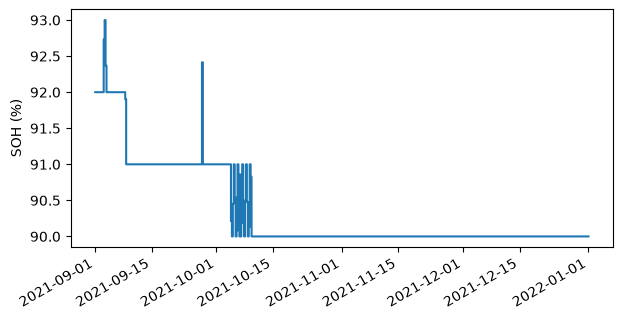

In [4]:
ax = frame['SOH'].plot(figsize=(7, 3.5), drawstyle='steps-post')
ax.set_xlabel('')
ax.set_ylabel('SOH (%)')
plt.show()

SOH steps down from 92 to 90 percent over the four months. Values between the steps are averages over a 20,000 s window.